<a href="https://colab.research.google.com/github/Insight-Syndicate/DSPL_GCW/blob/main/Models/Random_Forest_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import Necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import auth
from googleapiclient.discovery import build

# Authenticate and build Google Drive API service
auth.authenticate_user()
drive_service = build('drive', 'v3')

# Public Google Drive folder and file name
folder_id = "1XkRUF4MCrgqzis3v2C7Bx9GQaK5XgFZI"
file_name = "clean_train.csv"

# Search for the file
results = drive_service.files().list(q=f"'{folder_id}' in parents and name='{file_name}'",
                                     fields="files(id)").execute()
files = results.get("files", [])

if files:
    clean_train = pd.read_csv(f"https://drive.google.com/uc?id={files[0]['id']}")
    print(clean_train)
else:
    print(f"'{file_name}' not found in the folder.")

        Customer_ID outlet_city  luxury_sales  fresh_sales  dry_sales  \
0        10493832.0    Kelaniya       1209.60       756.00    5292.00   
1        10178643.0    Moratuwa       1590.12      1060.08    6007.12   
2        10513916.0     Wattala       2288.88      1481.04    9155.52   
3        10334589.0     Wattala       2274.94      1739.66    9099.76   
4        10458365.0    Kelaniya       2345.49      2069.55    9243.99   
...             ...         ...           ...          ...        ...   
774140   10197979.0     Gampaha       3893.40      3893.40    3448.44   
774141   10494575.0  Katunayake       6095.86      5557.99    6275.15   
774142   10565682.0     Colombo       5121.42      4820.16    4669.53   
774143   10351977.0       Kandy       6311.76      6311.76    5940.48   
774144   10637635.0     Negombo       5833.50      6027.95    6611.30   

        cluster_catgeory  outlet_city_encoded  
0                      4                   11  
1                      1   

# **Data Scaling**

## **Train**

We are using the robust scaller since our data is skewed and luxury sales has outliers. Since this technique scales using the median and IQR it is best suited to deal with the skewness and the extreme values.

In [4]:
from sklearn.preprocessing import RobustScaler
# Identify numerical columns
numerical_columns = ['luxury_sales', 'fresh_sales', 'dry_sales']

# Initialize RobustScaler
DSPL_scaler = RobustScaler()

# Fit on training numerical data and transform both train & test
clean_train[numerical_columns] = DSPL_scaler.fit_transform(clean_train[numerical_columns])
clean_train

,Customer_ID,outlet_city,luxury_sales,fresh_sales,dry_sales,cluster_catgeory,outlet_city_encoded
0,10493832.0,Kelaniya,-0.449457,-0.514864,0.291089,4,11
1,10178643.0,Moratuwa,-0.111244,-0.454663,0.424165,1,13
2,10513916.0,Wattala,0.509826,-0.371322,1.010049,4,19
3,10334589.0,Wattala,0.497436,-0.320120,0.999672,4,19
4,10458365.0,Kelaniya,0.560142,-0.254809,1.026512,4,11
...,...,...,...,...,...,...,...
774140,10197979.0,Gampaha,1.935952,0.106275,-0.051979,3,4
774141,10494575.0,Katunayake,3.893537,0.435829,0.474042,3,10
774142,10565682.0,Colombo,3.027438,0.289754,0.175253,3,1
774143,10351977.0,Kandy,4.085433,0.585060,0.411764,3,9


#**Random Forest Model**

In [5]:
# Importing code bloxks from the scikit learn library
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
# Checking for feature balance in the train data
clean_train['cluster_catgeory'].value_counts()

,count
cluster_catgeory,
1,188980
4,172439
6,169215
2,155064
3,48907
5,39540


Since customer Id has no prediction value and is only a unique identifier it is not included in the features in the x dataframe since including it migh lead to over fitting the model.

In [7]:
# Difine X and Y variables
X = clean_train[['luxury_sales','fresh_sales','dry_sales','outlet_city_encoded']]
y = clean_train['cluster_catgeory']

In [8]:
# Split data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [9]:
# Verify dimensions
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (464487, 4)
y_train shape: (464487,)


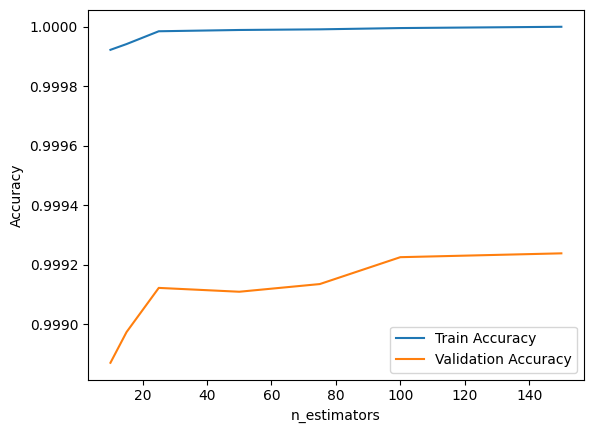

In [ ]:
estimators_range = [10, 15, 25, 25, 50, 75, 100, 150]
train_scores, val_scores = [], []

for n in estimators_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    val_scores.append(accuracy_score(y_val, model.predict(X_val)))

plt.plot(estimators_range, train_scores, label="Train Accuracy")
plt.plot(estimators_range, val_scores, label="Validation Accuracy")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.legend()
plt.showw()

In [ ]:
# Grid Search
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [10, 15, 20, 25, 50, 75, 100]}
rf = RandomForestClassifier()
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_n_estimators = grid_search.best_params_['n_estimators']
print(f"Best n_estimators: {best_n_estimators}")

Best n_estimators: 100


In [10]:
# creating the randome forest classifier (rfc) model
rfc_model = RandomForestClassifier(n_estimators=100, random_state=42)

n_estimators is the hyperparameter in random forest which tells the number of decision trees in the forest. Higher n_estimators mean higher accuracy but also higher computational cost and time. Therefore, 100 has been settled on as the balance between accuracy, computational cost as futher increase in this hyper parameter would only provide dimnishing returns.

In [11]:
# Train the model
rfc_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [12]:
# Predict using the x_test data
y_pred = rfc_model.predict(X_test)

In [13]:
# Evaluate the model
MSE = mean_squared_error(y_test, y_pred)
r2_= r2_score(y_test, y_pred)
Acs = accuracy_score(y_test, y_pred)

print(f"MSE:{MSE}")
print(f"R2:{r2_}")
print(f"Accuracy:{Acs}")

MSE:0.006426444658300448
R2:0.9981602952714446
Accuracy:0.9993282912115947


In [14]:
# confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[37862,     2,     0,    11,     0,     1],
       [    2, 30903,     0,     2,     2,    13],
       [    0,     0,  9745,     0,     2,     1],
       [   21,     1,     1, 34345,     2,     0],
       [    0,     0,    12,     1,  7948,     1],
       [    0,    20,     4,     3,     2, 33922]])

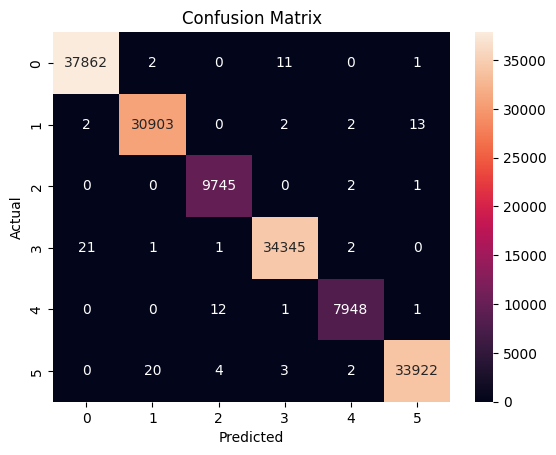

In [15]:
# heatmap of contribution matrix
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

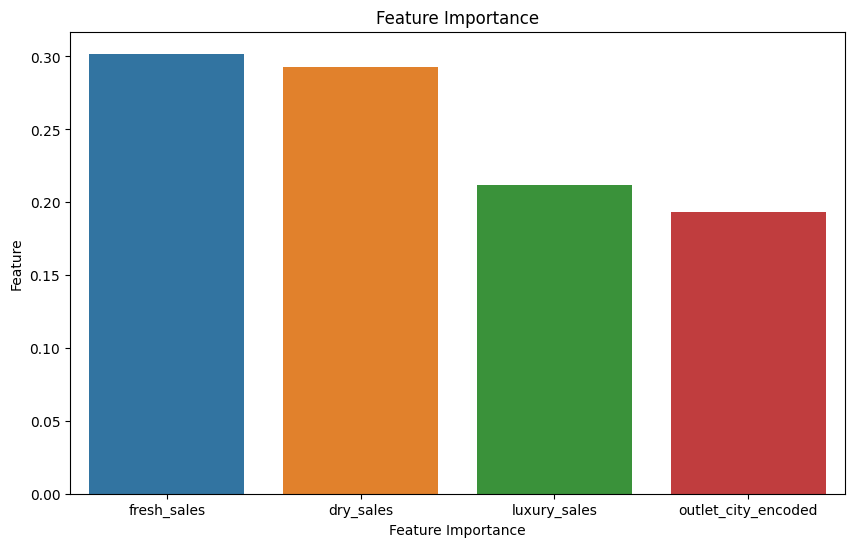

In [16]:
# importance of each feature
feature_importance = rfc_model.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# plot
plt.figure(figsize=(10, 6))
sns.barplot(y='Importance', x='Feature', data=importance_df, hue='Feature')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

In [17]:
# classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00     37876
           2       1.00      1.00      1.00     30922
           3       1.00      1.00      1.00      9748
           4       1.00      1.00      1.00     34370
           5       1.00      1.00      1.00      7962
           6       1.00      1.00      1.00     33951

    accuracy                           1.00    154829
   macro avg       1.00      1.00      1.00    154829
weighted avg       1.00      1.00      1.00    154829



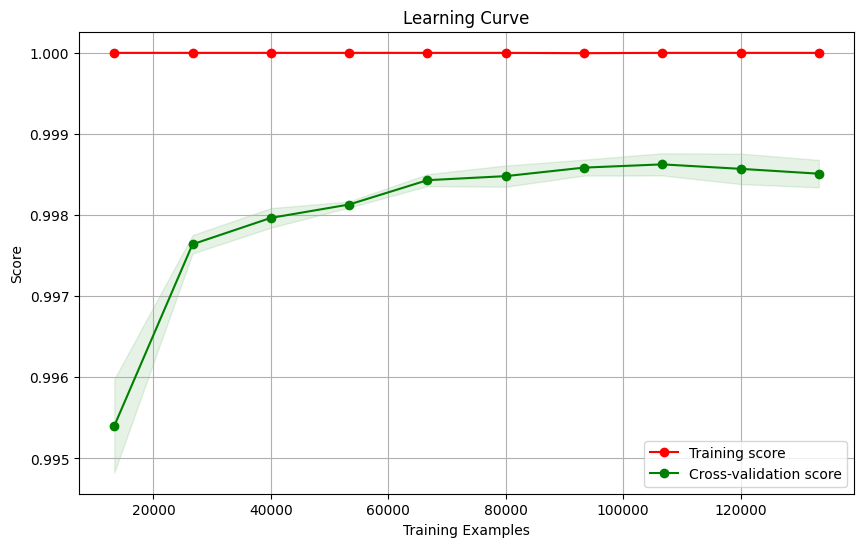

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier

# Subset of the training data
sample_size = 200000
train_sample = clean_train.sample(n=sample_size, random_state=42)
X_sample = train_sample[['luxury_sales', 'fresh_sales', 'dry_sales', 'outlet_city_encoded']]
y_sample = train_sample['cluster_catgeory']

rfc_model = RandomForestClassifier(n_estimators=100, n_jobs=-1)

# The learning curve
train_sizes, train_scores, test_scores = learning_curve(
    rfc_model, X_sample, y_sample, cv=3, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Mean and standard deviation for training and test scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plotting the learning curve
plt.figure(figsize=(10, 6))
plt.title("Learning Curve")
plt.xlabel("Training Examples")
plt.ylabel("Score")
plt.grid()

# Plotting the training scores
plt.fill_between(
    train_sizes, train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std, alpha=0.1, color="r"
)
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")

# Plotting the cross-validation scores
plt.fill_between(
    train_sizes, test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std, alpha=0.1, color="g"
)
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

# Adding legend and showing the plot
plt.legend(loc="best")
plt.show()

## **Evaluation**

In [18]:
# Predict on training, validation, and test sets
y_train_pred = rfc_model.predict(X_train)
y_val_pred = rfc_model.predict(X_val)
y_test_pred = rfc_model.predict(X_test)

# Calculate accuracy and MSE for training, validation, and test sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# Print the results
print(f"Training Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")
print(f"Training MSE: {train_mse:.4f}, Validation MSE: {val_mse:.4f}, Test MSE: {test_mse:.4f}")

# Determine if the model is overfitting or underfitting
if train_accuracy > val_accuracy and val_accuracy > test_accuracy:
    print("The model is overfitting.")
elif train_accuracy < val_accuracy:
    print("The model is underfitting.")
else:
    print("The model is well-fitted.")

Training Accuracy: 1.0000, Validation Accuracy: 0.9992, Test Accuracy: 0.9993
Training MSE: 0.0000, Validation MSE: 0.0073, Test MSE: 0.0064
The model is well-fitted.


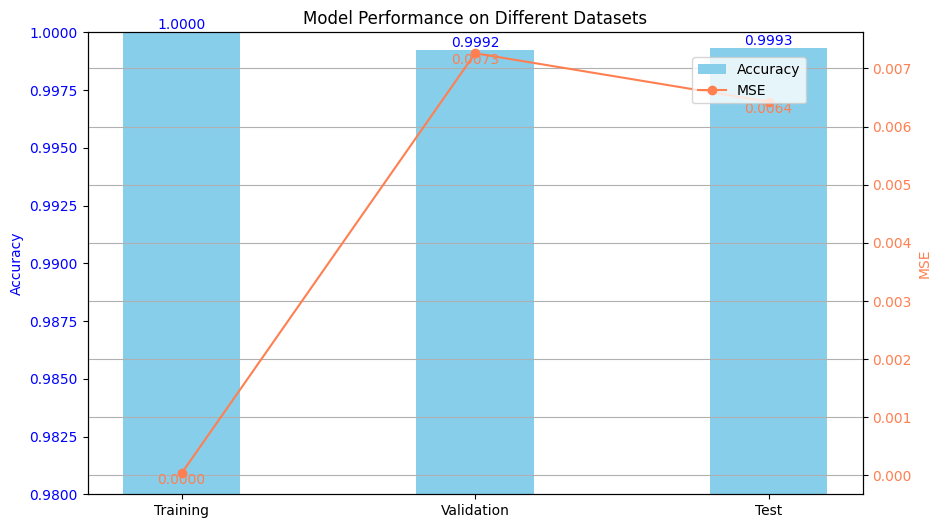

In [19]:
# Data
datasets = ['Training', 'Validation', 'Test']
accuracy_scores = [train_accuracy, val_accuracy, test_accuracy]
mse_scores = [train_mse, val_mse, test_mse]

# Create subplots and secon axis
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Bar plot for Accuracy
bars = ax1.bar(datasets, accuracy_scores, color='skyblue', label='Accuracy', width=0.4)
ax1.set_ylabel('Accuracy', color='blue')
ax1.tick_params('y', labelcolor='blue')
ax1.set_ylim(0.98, 1.0)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.4f}', ha='center', va='bottom', color="blue")

# Line plot for MSE
line = ax2.plot(datasets, mse_scores, color='coral', marker='o', label='MSE')
ax2.set_ylabel('MSE', color='coral')
ax2.tick_params('y', labelcolor='coral')
for i, value in enumerate(mse_scores):
    ax2.text(datasets[i], value, f'{value:.4f}', ha='center', va='top', color="coral")


# Set labels and title
plt.title('Model Performance on Different Datasets')
plt.xlabel('Dataset')

# Add grid and legend
plt.grid(True)
fig.legend(loc="upper right", bbox_to_anchor=(0.85, 0.85))

# Display the plot
plt.show()

# Export the Model

In [20]:
import pickle

In [21]:
# Specify the filename
filename = 'random_forest_model.sav'

# Save the model using pickle
pickle.dump(rfc_model, open(filename, 'wb'))